# K-means 알고리즘으로 붓꽃 품종 구분하기

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()

In [2]:
import pandas as pd

In [3]:
from sklearn.cluster import KMeans
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
iris_df

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
KM = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
KM.fit(iris_df)

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=0)

In [5]:
KM.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [6]:
iris_df['target'] = iris.target
iris_df['cluster'] = KM.labels_
iris_df.groupby(['target', 'cluster'])['sepal_length'].count()

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

# silhouette 계수 측정

In [7]:
from sklearn.metrics import silhouette_samples, silhouette_score
score_samples = silhouette_samples(iris.data, iris_df['cluster'])
iris_df['silhouette_coeff'] = score_samples
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797
3,4.6,3.1,1.5,0.2,0,1,0.804352
4,5.0,3.6,1.4,0.2,0,1,0.848918


In [8]:
silhouette_score(iris.data, iris_df['cluster'])

np.float64(0.5511916046195919)

# 실루엣 차트

In [9]:
import matplotlib.pyplot as plt

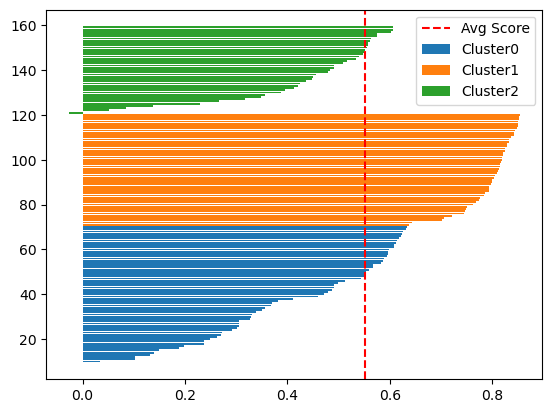

In [10]:
y_lower = 10
for i in range(3):
    cluster_i = score_samples[iris_df['cluster'] == i]
    cluster_i.sort()
    y_upper = y_lower + len(cluster_i)
    plt.barh(range(y_lower, y_upper), cluster_i, label=f'Cluster{i}')
    y_lower = y_upper
avg_score = silhouette_score(iris.data, iris_df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--', label='Avg Score')
plt.legend()
plt.show()

# scree plot

In [11]:
KM.inertia_

78.85566582597728

In [12]:
scree_df = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:14

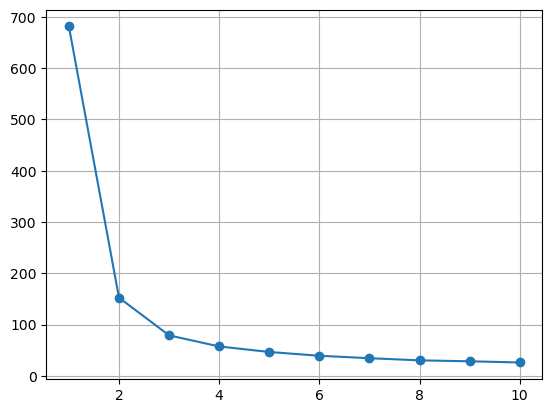

In [13]:
inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k,n_init=10,random_state=42)
    kmeans.fit(scree_df)
    inertia.append(kmeans.inertia_)
    
plt.plot(k_values,inertia, marker='o')
plt.grid()
plt.show()

# PCA > 2개의 주성분으로 축소

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)
pca_transformed.shape

(150, 2)

In [15]:
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

In [16]:
iris_df['pca_x'] = pca_transformed[:,0]
iris_df['pca_y'] = pca_transformed[:,1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,0.828797,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,0.804352,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,0.848918,-2.728717,0.326755


# PCA 결과 시각화

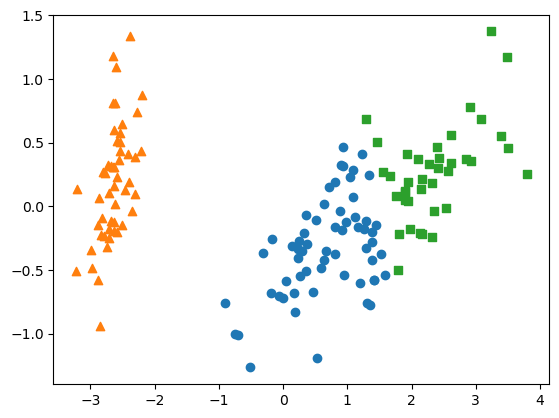

In [17]:
plt.scatter(
            x=iris_df.loc[iris_df['cluster'] == 0, 'pca_x'],
            y= iris_df.loc[iris_df['cluster'] == 0, 'pca_y'],
            marker='o'
           )
plt.scatter(
            x=iris_df.loc[iris_df['cluster'] == 1, 'pca_x'],
            y= iris_df.loc[iris_df['cluster'] == 1, 'pca_y'],
            marker='^'
           )
plt.scatter(
            x=iris_df.loc[iris_df['cluster'] == 2, 'pca_x'],
            y= iris_df.loc[iris_df['cluster'] == 2, 'pca_y'],
            marker='s'
           )
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(iris.data)
X_scaled = scaler.fit_transform(iris.data)

In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(X_scaled)
pca_transformed.shape

(150, 2)

In [20]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

In [21]:
iris_df['pca_x'] = pca_transformed[:,0]
iris_df['pca_y'] = pca_transformed[:,1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-2.264703,0.480027
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.080961,-0.674134
2,4.7,3.2,1.3,0.2,0,1,0.828797,-2.364229,-0.341908
3,4.6,3.1,1.5,0.2,0,1,0.804352,-2.299384,-0.597395
4,5.0,3.6,1.4,0.2,0,1,0.848918,-2.389842,0.646835


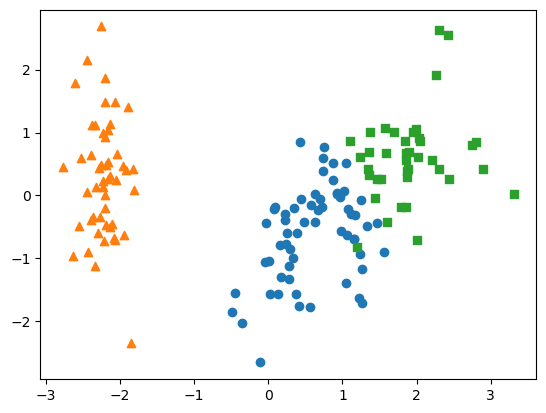

In [22]:
plt.scatter(
            x=iris_df.loc[iris_df['cluster'] == 0, 'pca_x'],
            y= iris_df.loc[iris_df['cluster'] == 0, 'pca_y'],
            marker='o'
           )
plt.scatter(
            x=iris_df.loc[iris_df['cluster'] == 1, 'pca_x'],
            y= iris_df.loc[iris_df['cluster'] == 1, 'pca_y'],
            marker='^'
           )
plt.scatter(
            x=iris_df.loc[iris_df['cluster'] == 2, 'pca_x'],
            y= iris_df.loc[iris_df['cluster'] == 2, 'pca_y'],
            marker='s'
           )
plt.show()

# 클러스터링 실습

In [23]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
cancer_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [93]:
KM = KMeans(n_clusters=2, init='k-means++', max_iter=300, random_state=0)
KM.fit(cancer_df)
cancer_df['target'] = cancer.target
cancer_df['cluster'] = KM.labels_
cancer_df.groupby(['target', 'cluster'])['mean radius'].count()

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


target  cluster
0       0           82
        1          130
1       0          356
        1            1
Name: mean radius, dtype: int64

In [94]:
silhouette_score(cancer.data, cancer_df['cluster'])

np.float64(0.6972646156059464)

In [95]:
score_samples = silhouette_samples(cancer.data, cancer_df['cluster'])
cancer_df['silhouette_coeff'] = score_samples
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,9.192837,1.948583,-1.123166,3.633731,-1.195110,1.411425,2.159370,-0.398407,-0.157119,-0.877405
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,2.387802,-3.768172,-0.529293,1.118264,0.621775,0.028656,0.013358,0.240988,-0.711905,1.106994
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,5.733896,-1.075174,-0.551748,0.912083,-0.177086,0.541452,-0.668166,0.097373,0.024062,0.454273
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,7.122953,10.275589,-3.232790,0.152547,-2.960878,3.053422,1.429912,1.059563,-1.405445,-1.116978
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,3.935302,-1.948072,1.389767,2.940639,0.546747,-1.226495,-0.936213,0.636376,-0.263804,0.377707


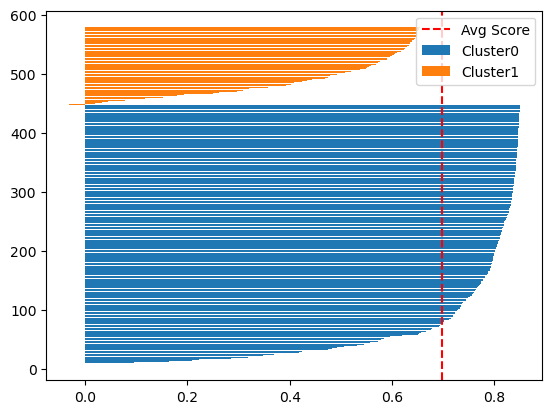

In [97]:
y_lower = 10
for i in range(2):
    cluster_i = score_samples[cancer_df['cluster'] == i]
    cluster_i.sort()
    y_upper = y_lower + len(cluster_i)
    plt.barh(range(y_lower, y_upper), cluster_i, label=f'Cluster{i}')
    y_lower = y_upper
avg_score = silhouette_score(cancer.data, cancer_df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--', label='Avg Score')
plt.legend()
plt.show()

In [98]:
scree_df = cancer_df[cancer.feature_names]

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:14

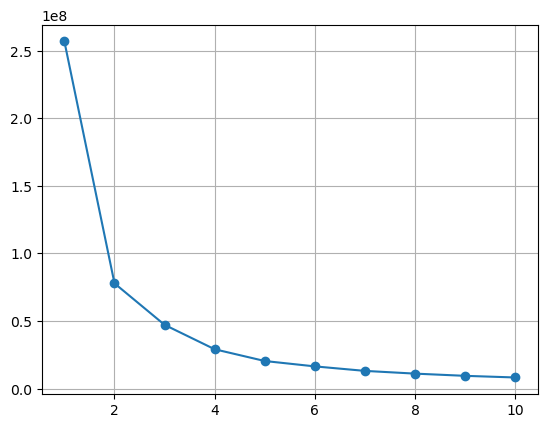

In [99]:
inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k,n_init=10,random_state=42)
    kmeans.fit(scree_df)
    inertia.append(kmeans.inertia_)
    
plt.plot(k_values,inertia, marker='o')
plt.grid()
plt.show()

In [139]:
# pca 2개의 주성분
pca = PCA(n_components=12)
pca_transformed = pca.fit_transform(cancer.data)
pca_transformed.shape

(569, 12)

In [140]:
pca.explained_variance_ratio_.sum()

np.float64(0.9999999812220506)

In [141]:
for i in range(len(pca_transformed[0])):
    cancer_df['pca_' + str(i + 1)] = pca_transformed[:,i]

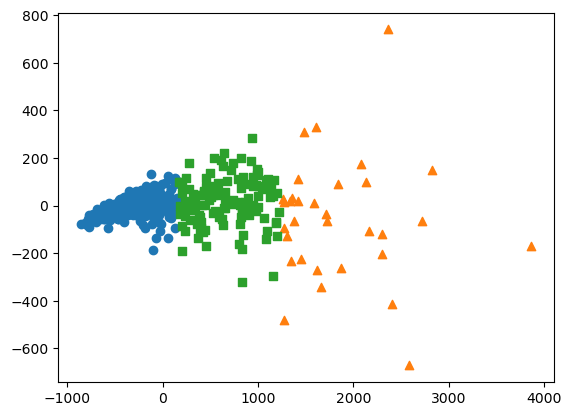

In [33]:
plt.scatter(
            x=cancer_df.loc[cancer_df['cluster'] == 0, 'pca_x'],
            y= cancer_df.loc[cancer_df['cluster'] == 0, 'pca_y'],
            marker='o'
           )
plt.scatter(
            x=cancer_df.loc[cancer_df['cluster'] == 1, 'pca_x'],
            y= cancer_df.loc[cancer_df['cluster'] == 1, 'pca_y'],
            marker='^'
           )
plt.scatter(
            x=cancer_df.loc[cancer_df['cluster'] == 2, 'pca_x'],
            y= cancer_df.loc[cancer_df['cluster'] == 2, 'pca_y'],
            marker='s'
           )
plt.show()

In [142]:
KM1 = KMeans(n_clusters=2, init='k-means++', max_iter=300, random_state=0)
KM1.fit(cancer_df[['pca_' + str(i + 1) for i in range(len(pca_transformed[0]))]])
cancer_df['target'] = cancer.target
cancer_df['cluster1'] = KM1.labels_
cancer_df.groupby(['target', 'cluster1'])['mean radius'].count()

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


target  cluster1
0       0            82
        1           130
1       0           356
        1             1
Name: mean radius, dtype: int64

In [143]:
silhouette_score(cancer.data, cancer_df['cluster1'])

np.float64(0.6972646156059464)

In [36]:
scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.fit_transform(cancer.data)

In [114]:
pca = PCA(n_components=12)
pca_transformed = pca.fit_transform(X_scaled)
pca_transformed.shape

(569, 12)

In [115]:
pca.explained_variance_ratio_.sum()

np.float64(0.9700713832166317)

In [116]:
for i in range(len(pca_transformed[0])):
    cancer_df['pca_' + str(i + 1)] = pca_transformed[:,i]

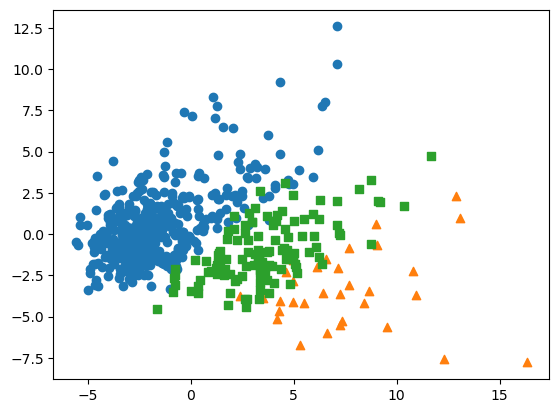

In [48]:
plt.scatter(
            x=cancer_df.loc[cancer_df['cluster'] == 0, 'pca_1'],
            y= cancer_df.loc[cancer_df['cluster'] == 0, 'pca_2'],
            marker='o'
           )
plt.scatter(
            x=cancer_df.loc[cancer_df['cluster'] == 1, 'pca_1'],
            y= cancer_df.loc[cancer_df['cluster'] == 1, 'pca_2'],
            marker='^'
           )
plt.scatter(
            x=cancer_df.loc[cancer_df['cluster'] == 2, 'pca_1'],
            y= cancer_df.loc[cancer_df['cluster'] == 2, 'pca_2'],
            marker='s'
           )
plt.show()

In [117]:
KM1 = KMeans(n_clusters=2, init='k-means++', max_iter=300, random_state=0)
KM1.fit(cancer_df[['pca_' + str(i + 1) for i in range(len(pca_transformed[0]))]])
cancer_df['target'] = cancer.target
cancer_df['cluster1'] = KM1.labels_
cancer_df.groupby(['target', 'cluster1'])['mean radius'].count()

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


target  cluster1
0       0            37
        1           175
1       0           344
        1            13
Name: mean radius, dtype: int64

In [118]:
silhouette_score(cancer.data, cancer_df['cluster1'])

np.float64(0.5033171942276382)